## 関数分割版（ノートブック内で中身を確認できる版）

このセクションでは、処理を次の単位に分割しています。

- **build_common_histogram**: 各ステップのヒストグラムを共通ビンに再サンプリングして質量（mass）を作る
- **normalize_to_unit_range**: 値を `[-1, 1]` に正規化する（scale 自動推定可）
- **quantize_uniform_signed / decompose_5bit_codes**: 量子化と Total/MSB/LSB 分解
- **inject_gaussian_noise_on_mass**: 量子化後の質量分布にガウスノイズを注入
- **plot_bar_distribution**: 統一スタイルで棒グラフ描画
- **analyze_bit_decomposition_with_noise_notebook**: 上記をつなぐ統合関数

必要な箇所だけ差し替えやすいよう、関数間の依存を最小限にしています。

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def build_common_histogram(data, key="states", n_bins=200):
    """各ステップのhistを共通ビンへ再サンプリングしてmassを返す。"""
    mins, maxs = [], []
    for row in data:
        if key in row:
            mins.append(float(row[key]["min"]))
            maxs.append(float(row[key]["max"]))
    if not mins:
        raise ValueError(f"{key} not found in data")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths_common = np.diff(edges_common)
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])
    hist_density_sum = np.zeros(n_bins, dtype=float)

    for row in data:
        if key not in row:
            continue
        h = np.asarray(row[key]["hist"], dtype=float)
        step_min = float(row[key]["min"])
        step_max = float(row[key]["max"])

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_density_sum[idx] += (cnt / w) if (w > 0) else cnt

    mass_common = hist_density_sum * widths_common
    return centers_common, widths_common, edges_common, mass_common


def normalize_to_unit_range(values, scale=None, active_mask=None):
    """値を[-1,1]に正規化する。scale=Noneなら有効領域から自動推定。"""
    values = np.asarray(values, dtype=float)
    if active_mask is None:
        active_mask = np.ones_like(values, dtype=bool)

    if scale is None:
        active = np.abs(values[active_mask])
        scale = float(active.max()) if active.size > 0 else 1.0
    if scale <= 0:
        raise ValueError("scale must be positive")

    values_norm = np.clip(values / scale, -1.0, 1.0)
    return values_norm, float(scale)


def quantize_uniform_signed(values_norm, n_bits=5):
    """[-1,1]一様量子化。戻り値: (index, center, step)。"""
    levels = 2 ** n_bits
    step = 2.0 / (levels - 1)
    indices = np.round((values_norm + 1.0) / step).astype(int)
    indices = np.clip(indices, 0, levels - 1)
    centers = -1.0 + indices * step
    return indices, centers, step


def decompose_5bit_codes(indices):
    """5bit codeをTotal/MSB/LSB/Reconstructedに分解。"""
    code_total = indices.astype(float) - 15.5
    code_msb = np.trunc(code_total / 4.0) * 4.0
    code_lsb = code_total - code_msb
    code_recon = code_msb + code_lsb
    return {
        "total": code_total,
        "msb": code_msb,
        "lsb": code_lsb,
        "reconstructed": code_recon,
    }


def aggregate_mass_by_values(values, masses, fixed_bins=None, atol=1e-10):
    """同じ離散値ごとに質量を集約。"""
    values = np.asarray(values, dtype=float)
    masses = np.asarray(masses, dtype=float)
    bins = np.asarray(fixed_bins, dtype=float) if fixed_bins is not None else np.unique(np.round(values, 10))
    out = np.array([masses[np.isclose(values, b, atol=atol)].sum() for b in bins], dtype=float)
    return bins, out


def inject_gaussian_noise_on_mass(value_points, mass_points, std=0.02, n_bins_out=200):
    """離散質量を連続ビンへ拡散（std<=0で拡散なし）。"""
    edges = np.linspace(-1.0, 1.0, n_bins_out + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    y_mass = np.zeros(n_bins_out, dtype=float)

    if std <= 0.0:
        idx = np.searchsorted(edges, value_points, side="right") - 1
        idx = np.clip(idx, 0, n_bins_out - 1)
        for i, m in zip(idx, mass_points):
            y_mass[i] += m
    else:
        for c, m in zip(value_points, mass_points):
            if m <= 0:
                continue
            kernel = np.exp(-0.5 * ((centers - c) / std) ** 2)
            s = kernel.sum()
            if s > 0:
                y_mass += m * (kernel / s)

    return centers, y_mass, widths


def plot_bar_distribution(x, y, widths, x_tick_step=0.6, title=None):
    """棒グラフ描画（目盛り0.6固定、表示範囲はデータに応じて拡張）。"""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x, y, width=widths * 0.9, color="steelblue", edgecolor="black", linewidth=0.3, zorder=3)
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", labelsize=20, width=1.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(x_tick_step))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

    half_w = 0.5 * float(np.max(widths)) if len(widths) > 0 else 0.0
    x_min_data = float(np.min(x) - half_w)
    x_max_data = float(np.max(x) + half_w)
    x_min = np.floor(x_min_data / x_tick_step) * x_tick_step
    x_max = np.ceil(x_max_data / x_tick_step) * x_tick_step
    ax.set_xlim(x_min, x_max)

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.tight_layout()
    plt.show()


def analyze_bit_decomposition_with_noise_notebook(
    data, key="states", n_bins_common=200, n_bits=5, std=0.02, n_bins_plot=200, base_scale=None
):
    """統合関数: 共通hist -> 正規化 -> 量子化 -> 分解 -> ノイズ注入 -> 描画。"""
    # 1) 前提の確認
    if n_bits != 5:
        raise ValueError("この分解ロジックは現状5bit前提です")

    # 2) 共通ビンでhistを構築
    centers_common, _, _, mass_common = build_common_histogram(data, key=key, n_bins=n_bins_common)
    if mass_common.sum() <= 0:
        raise ValueError("mass is empty")

    # 3) 正規化（scale=Noneなら有効領域から自動推定）
    values_norm, scale = normalize_to_unit_range(
        centers_common, scale=base_scale, active_mask=(mass_common > 0)
    )

    # 4) 量子化してコードに分解
    q_idx, _, q_step = quantize_uniform_signed(values_norm, n_bits=n_bits)

    # 5) コードをTotal/MSB/LSB/Reconstructedに分解
    codes = decompose_5bit_codes(q_idx)

    msb_bins_fixed = np.array([-12, -8, -4, 0, 4, 8, 12], dtype=float)
    lsb_bins_fixed = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5], dtype=float)

    t_bins, t_mass = aggregate_mass_by_values(codes["total"], mass_common)
    m_bins, m_mass = aggregate_mass_by_values(codes["msb"], mass_common, fixed_bins=msb_bins_fixed)
    l_bins, l_mass = aggregate_mass_by_values(codes["lsb"], mass_common, fixed_bins=lsb_bins_fixed)
    r_bins, r_mass = aggregate_mass_by_values(codes["reconstructed"], mass_common)

    def _component_xyw(code_bins, code_mass):
        comp_values = code_bins * q_step
        comp_norm, comp_scale = normalize_to_unit_range(
            comp_values, scale=None, active_mask=(code_mass > 0)
        )
        x_norm, y_mass, w_norm = inject_gaussian_noise_on_mass(
            comp_norm, code_mass, std=std, n_bins_out=n_bins_plot
        )
        y = (y_mass / y_mass.sum() * 100.0) if y_mass.sum() > 0 else y_mass
        x = x_norm * comp_scale * scale
        w = w_norm * comp_scale * scale
        return x, y, w, comp_scale

    t_x, t_y, t_w, t_s = _component_xyw(t_bins, t_mass)
    m_x, m_y, m_w, m_s = _component_xyw(m_bins, m_mass)
    l_x, l_y, l_w, l_s = _component_xyw(l_bins, l_mass)
    r_x, r_y, r_w, r_s = _component_xyw(r_bins, r_mass)

    # 6) 可視化
    plot_bar_distribution(t_x, t_y, t_w, title="Total")
    plot_bar_distribution(m_x, m_y, m_w, title="MSB")
    plot_bar_distribution(l_x, l_y, l_w, title="LSB")
    plot_bar_distribution(r_x, r_y, r_w, title="Reconstructed")

    recon_err = np.max(np.abs((codes["reconstructed"] - codes["total"]) * q_step))
    print(f"base scale = {scale:.6f}")
    print(f"quant step = {q_step:.6f}")
    print(f"noise std (normalized) = {std}")
    print(f"Total normalize scale = {t_s:.6f}")
    print(f"MSB normalize scale = {m_s:.6f}")
    print(f"LSB normalize scale = {l_s:.6f}")
    print(f"Reconstructed normalize scale = {r_s:.6f}")
    print(f"max |(MSB+LSB)-Total| (value) = {recon_err:.12f}")

    return {
        "total_x": t_x, "total_y": t_y,
        "msb_x": m_x, "msb_y": m_y,
        "lsb_x": l_x, "lsb_y": l_y,
        "recon_x": r_x, "recon_y": r_y,
    }

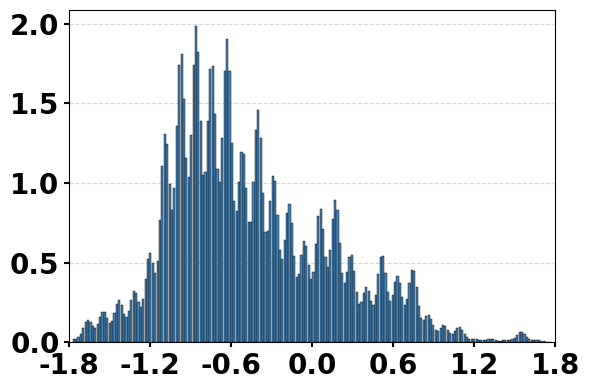

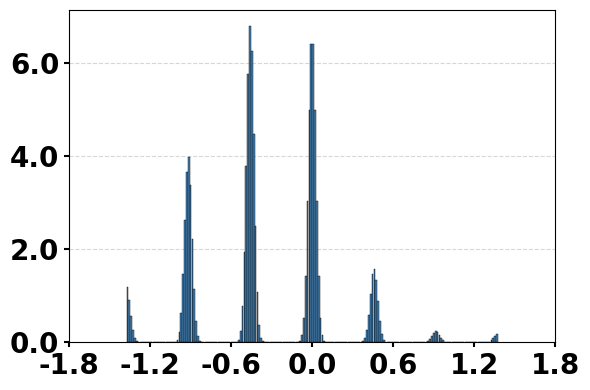

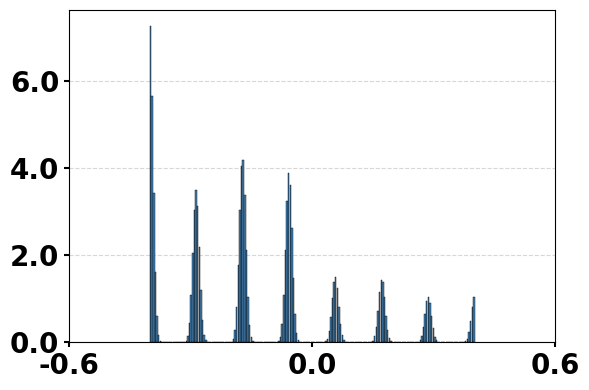

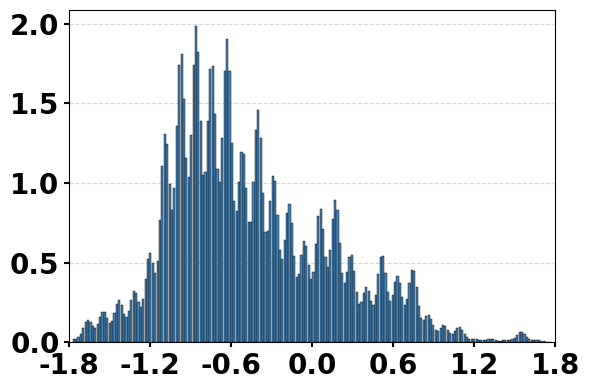

base scale = 1.775942
quant step = 0.064516
noise std (normalized) = 0.02
Total normalize scale = 1.000000
MSB normalize scale = 0.774194
LSB normalize scale = 0.225806
Reconstructed normalize scale = 1.000000
max |(MSB+LSB)-Total| (value) = 0.000000000000


In [8]:
import json
with open("/work/robomimic/logs/quantize/all/calibration/u256/Seed4.json") as f:
    data = json.load(f)
# 実行例（ノートブック内の分割関数を使用）
results_in_notebook = analyze_bit_decomposition_with_noise_notebook(
    data=data,
    key="states",
    n_bins_common=200,
    n_bits=5,
    std=0.02,
    n_bins_plot=200,
    base_scale=None,
    )